# ShuffleNetV2 - Individual Baseline Run


In [1]:
import sys
import os

import torch

sys.path.append(os.path.abspath("../src"))

from models import ShuffleNetV2
from data import prepare_full_dataframe, prepare_data, sample_image_path, get_transforms
from train import run_training_pipeline, run_smoke_test
from train_eval import evaluate, predict_single_image
from utils import (
    get_device,
    get_model_path,
    plot_training_history_compact,
    plot_confusion_matrix_figure,
)
import config

print(f"Python:         {sys.executable}")
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")

Python:         c:\Users\profb\PROJECTS\cxr-model-benchmark\.venv\Scripts\python.exe
PyTorch:        2.11.0+cu128
CUDA available: True
GPU:            NVIDIA GeForce RTX 5090 Laptop GPU


In [2]:
dataset_path = config.DATASET_PATH
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print(f"Total images:    {len(df)}")
print(f"Unique patients: {df['Patient ID'].nunique()}")

Dataset location: C:\Users\profb\PROJECTS\datasets\NIH_Chest_X-Rays
Total images:    112120
Unique patients: 30805


In [3]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [4]:
train_loader, val_loader, test_loader = prepare_data(df)
device = get_device()

Using CUDA (GPU)


## Smoke Test


In [5]:
run_smoke_test(
    model_name="ShuffleNetV2",
    model_builder=lambda: ShuffleNetV2(num_classes=2, in_channels=1),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
)


=== Smoke test: ShuffleNetV2 (epochs=1, patience=1) ===

=== Training ShuffleNetV2 ===
Starting fresh training (resume disabled): c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\checkpoints\best_shufflenetv2\latest.pt
AMP enabled (bf16, grad scaler: off)
channels_last enabled
Scheduler active: type=warmup_cosine, start_epoch=1, steps_per_epoch=1, cosine_t_max=0


Train Epoch 1:   0%|          | 0/309 [00:15<?, ?it/s]

  VRAM a/r/p: 0.04G(0.2%)/0.68G(2.9%)/0.51G(2.1%)


Val Epoch 1:   0%|          | 0/66 [00:15<?, ?it/s]

Epoch 1/1 | ETA (Remaining): 00:00:00 | Total ETA: 00:02:36
  Train Loss: 0.6829 | Train Acc: 0.5574
  Val Loss: 0.6742 | Val Acc: 0.5954
  Val Precision: 0.6728
  Val Recall: 0.2199 | Val F1: 0.3314
  Val AUPRC: 0.5994
  Head LR: 1e-06
  Optimizer: AdamW | Weight Decay: 5e-05 | No-Decay Groups: 1
------------------------------------------------------------
Saved best model to c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\models\best_shufflenetv2.pt
------------------------------------------------------------


Val:   0%|          | 0/64 [00:16<?, ?it/s]

({'model': 'ShuffleNetV2',
  'epochs': 1,
  'batch_size': 256,
  'image_size': 256,
  'test_loss': 0.6745846085597511,
  'accuracy': 0.5923246689553703,
  'precision': 0.6845609654598419,
  'recall': 0.21825660076953696,
  'f1': 0.33098591549295775,
  'auprc': 0.6186106117589725},
 {'train_loss': [0.6829362081458046],
  'train_acc': [0.557440393239922],
  'val_loss': [0.6741513489080264],
  'val_acc': [0.5954130615147565],
  'val_precision': [0.6727634194831014],
  'val_recall': [0.21985446985446985],
  'val_f1': [0.33140730584663597],
  'val_auprc': [0.5994069959647489],
  'lr': [1e-06],
  'lr_backbone': [],
  'lr_head': [1e-06],
  'backbone_frozen': [True],
  'vram_peak_pct': [2.1188348075247636],
  'best_epoch': 1})

## Training


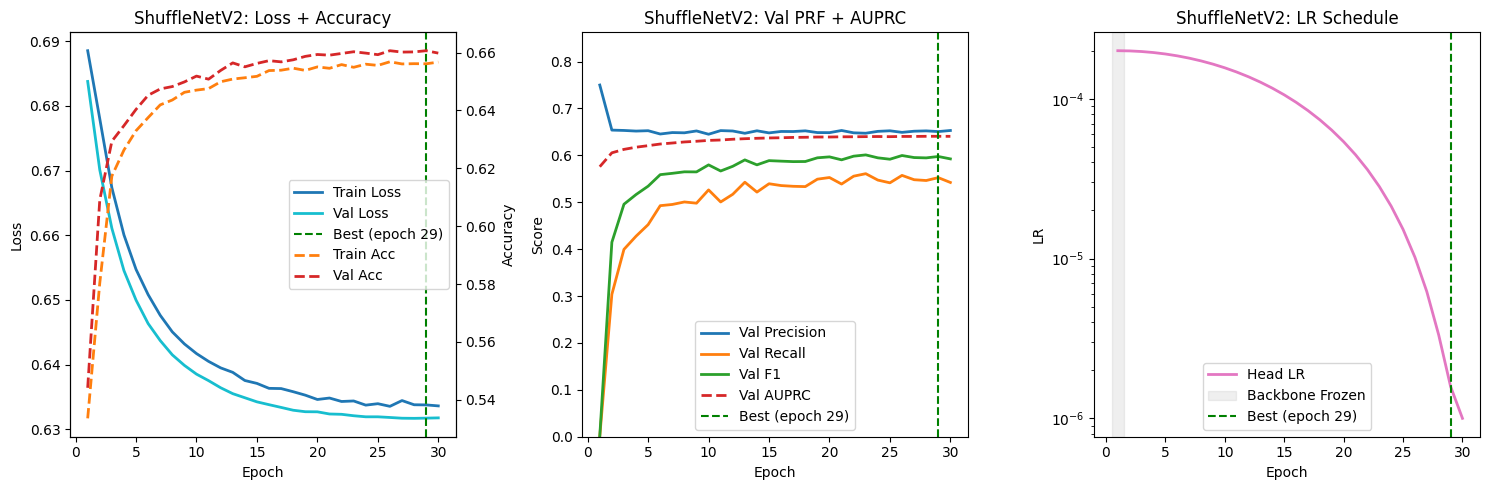

Val:   0%|          | 0/64 [00:00<?, ?it/s]

In [11]:
metrics, history = run_training_pipeline(
    model_name="ShuffleNetV2",
    model_builder=lambda: ShuffleNetV2(num_classes=2, in_channels=1),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=True,
)

## Results


### Val Metrics

In [12]:
best_epoch = history.get('best_epoch')
if best_epoch is not None:
    idx = best_epoch - 1  # Convert epoch (1-indexed) to array index (0-indexed)
    
    print("\n=== Best Epoch Validation Metrics ===")
    print(f"Epoch: {best_epoch}")
    print(f"Val Loss:      {history['val_loss'][idx]:.4f}")
    print(f"Val Accuracy:  {history['val_acc'][idx]:.4f}")
    print(f"Val Precision: {history['val_precision'][idx]:.4f}")
    print(f"Val Recall:    {history['val_recall'][idx]:.4f}")
    print(f"Val F1:        {history['val_f1'][idx]:.4f}")
    if 'val_auprc' in history and history['val_auprc']:
        print(f"Val AUPRC:     {history['val_auprc'][idx]:.4f}")



=== Best Epoch Validation Metrics ===
Epoch: 29
Val Loss:      0.6317
Val Accuracy:  0.6607
Val Precision: 0.6507
Val Recall:    0.5525
Val F1:        0.5976
Val AUPRC:     0.6407


### Test Metrics

In [13]:
# plot_training_history_compact(history, model_name="ShuffleNetV2")

print("\n=== Test Results ===")
print(f"Loss:        {metrics['test_loss']:.4f}")
print(f"Accuracy:    {metrics['accuracy']:.4f}")
print(f"Precision:   {metrics['precision']:.4f}")
print(f"Recall:      {metrics['recall']:.4f}")
print(f"F1:          {metrics['f1']:.4f}")
print(f"AUPRC:       {metrics['auprc']:.4f}")


=== Test Results ===
Loss:        0.6282
Accuracy:    0.6677
Precision:   0.6624
Recall:      0.5726
F1:          0.6142
AUPRC:       0.6577


Val:   0%|          | 0/64 [00:00<?, ?it/s]

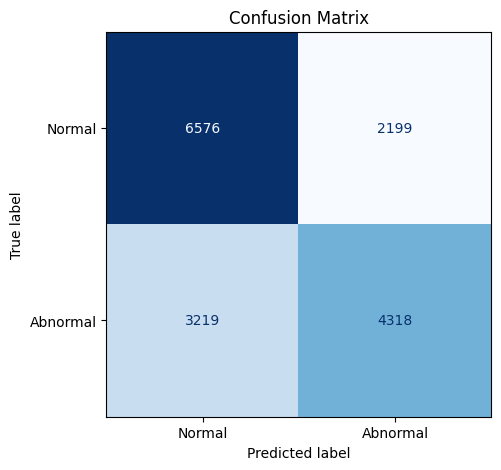

In [14]:
model = ShuffleNetV2(num_classes=2, in_channels=1).to(device)
model.load_state_dict(torch.load(get_model_path("best_shufflenetv2"), map_location=device))
criterion = torch.nn.CrossEntropyLoss()

_, _, _, _, _, test_labels, test_preds, _ = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
)

plot_confusion_matrix_figure(test_labels, test_preds, ["Normal", "Abnormal"])

In [15]:
import random

_, eval_transforms = get_transforms()
image_path = sample_image_path(df, split="test", seed=random.randint(0, 2**32 - 1))
result = predict_single_image(image_path, model, device, eval_transforms, df=df)

print("Image path:      ", image_path)
print("True label:      ", result["true_label"])
print("Predicted class: ", result["predicted_class"])
print("Probabilities:   ", result["probabilities"])

Image path:       C:\Users\profb\PROJECTS\datasets\NIH_Chest_X-Rays\images_008\images\00016429_039.png
True label:       normal
Predicted class:  abnormal
Probabilities:    {'normal': 0.43469953536987305, 'abnormal': 0.565300464630127}
